In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Setup successful")


Setup successful


In [3]:
import pandas as pd

df = pd.read_csv("../data/raw_expenses.csv")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw_expenses.csv'

In [4]:
import pandas as pd

df = pd.read_csv("../data/raw_expenses.csv")

df.head()

,TransactionID,ItemName,Category,Quantity,UnitPrice,TotalCost,PurchaseDate,Supplier,Buyer
0,TXN001,Desk Chair,Furniture,10,113.15,1131.50,2024-04-19,TechMart Inc.,Kelly Joseph
1,TXN002,Stapler,Office Supplies,16,12.62,201.92,2024-07-06,CloudSoft Corp.,Kelly Joseph
2,TXN003,Annual Software License,Software,1,5649.34,5649.34,2024-09-10,TechMart Inc.,Kelly Joseph
3,TXN004,Notepad,Stationery,13,2.92,37.96,2024-01-21,FurniWorks Ltd.,Luis Holland
4,TXN005,Notepad,Stationery,19,1.39,26.41,2024-02-03,TechMart Inc.,Cynthia Jenkins


In [5]:
df.columns

Index(['TransactionID', 'ItemName', 'Category', 'Quantity', 'UnitPrice',
       'TotalCost', 'PurchaseDate', 'Supplier', 'Buyer'],
      dtype='str')

In [6]:
df.shape


(500, 9)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   TransactionID  500 non-null    str    
 1   ItemName       500 non-null    str    
 2   Category       500 non-null    str    
 3   Quantity       500 non-null    int64  
 4   UnitPrice      500 non-null    float64
 5   TotalCost      500 non-null    float64
 6   PurchaseDate   500 non-null    str    
 7   Supplier       500 non-null    str    
 8   Buyer          500 non-null    str    
dtypes: float64(2), int64(1), str(6)
memory usage: 35.3 KB


In [8]:
df.columns

Index(['TransactionID', 'ItemName', 'Category', 'Quantity', 'UnitPrice',
       'TotalCost', 'PurchaseDate', 'Supplier', 'Buyer'],
      dtype='str')

In [9]:
df.describe()

,Quantity,UnitPrice,TotalCost
count,500.000000,500.000000,500.00000
mean,9.640000,854.245100,2481.16106
std,6.168834,2132.890832,3527.35316
min,1.000000,1.060000,1.56000
25%,4.000000,14.380000,145.92750
50%,10.000000,143.595000,918.56000
75%,15.000000,287.925000,3123.56750
max,20.000000,9909.240000,18494.60000


In [10]:
df["PurchaseDate"] = pd.to_datetime(df["PurchaseDate"])

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   TransactionID  500 non-null    str           
 1   ItemName       500 non-null    str           
 2   Category       500 non-null    str           
 3   Quantity       500 non-null    int64         
 4   UnitPrice      500 non-null    float64       
 5   TotalCost      500 non-null    float64       
 6   PurchaseDate   500 non-null    datetime64[us]
 7   Supplier       500 non-null    str           
 8   Buyer          500 non-null    str           
dtypes: datetime64[us](1), float64(2), int64(1), str(5)
memory usage: 35.3 KB


In [12]:
duplicates = df[df.duplicated(
    subset=["ItemName", "Supplier", "TotalCost"],
    keep=False
)]

duplicates

,TransactionID,ItemName,Category,Quantity,UnitPrice,TotalCost,PurchaseDate,Supplier,Buyer


In [13]:
duplicates.shape

(0, 9)

In [14]:
duplicates["TotalCost"].sum()

np.float64(0.0)

In [15]:
mean_cost = df["TotalCost"].mean()

std_cost = df["TotalCost"].std()

threshold = mean_cost + (2 * std_cost)

high_cost = df[df["TotalCost"] > threshold]

high_cost

,TransactionID,ItemName,Category,Quantity,UnitPrice,TotalCost,PurchaseDate,Supplier,Buyer
18,TXN019,Laptop,Electronics,19,815.19,15488.61,2024-10-22,TechMart Inc.,Jasmine Mcgee
30,TXN031,Laptop,Electronics,16,980.67,15690.72,2024-05-13,QuickDeliver Ltd.,Luis Holland
44,TXN045,Laptop,Electronics,12,835.25,10023.00,2024-08-05,QuickDeliver Ltd.,Laura White
53,TXN054,Laptop,Electronics,14,812.03,11368.42,2024-01-01,QuickDeliver Ltd.,Laura White
60,TXN061,Laptop,Electronics,20,920.32,18406.40,2024-11-17,TechMart Inc.,Dawn Padilla
133,TXN134,Laptop,Electronics,17,830.68,14121.56,2024-04-21,OfficeSupplies Co.,Todd James
136,TXN137,Laptop,Electronics,13,825.83,10735.79,2024-03-14,CloudSoft Corp.,Rebecca Bell
174,TXN175,Annual Software License,Software,1,9836.53,9836.53,2024-11-26,TechMart Inc.,Amy Warner
183,TXN184,Annual Software License,Software,1,9909.24,9909.24,2024-06-20,OfficeSupplies Co.,Melissa Mckee
209,TXN210,Laptop,Electronics,14,838.27,11735.78,2024-01-05,CloudSoft Corp.,Cynthia Jenkins


In [16]:
supplier_spend = df.groupby("Supplier")["TotalCost"].sum()

supplier_spend.sort_values(ascending=False)

Supplier
TechMart Inc.         328761.73
QuickDeliver Ltd.     285353.59
OfficeSupplies Co.    223580.85
FurniWorks Ltd.       202810.72
CloudSoft Corp.       200073.64
Name: TotalCost, dtype: float64

In [17]:
top_suppliers = supplier_spend.sort_values(ascending=False).head(10)

top_suppliers

Supplier
TechMart Inc.         328761.73
QuickDeliver Ltd.     285353.59
OfficeSupplies Co.    223580.85
FurniWorks Ltd.       202810.72
CloudSoft Corp.       200073.64
Name: TotalCost, dtype: float64

In [18]:
category_spend = df.groupby("Category")["TotalCost"].sum()

category_spend.sort_values(ascending=False)

Category
Electronics        697805.23
Software           336018.00
Furniture          172818.61
Accessories         20857.24
Stationery           6753.18
Office Supplies      6328.27
Name: TotalCost, dtype: float64

In [19]:
frequent_items = df["ItemName"].value_counts()

frequent_items.head(10)

ItemName
Stapler                    60
Laptop Bag                 56
Laptop                     56
Desk Chair                 53
Whiteboard                 49
Notepad                    48
Annual Software License    46
Printer                    45
Monitor                    45
Printer Ink                42
Name: count, dtype: int64

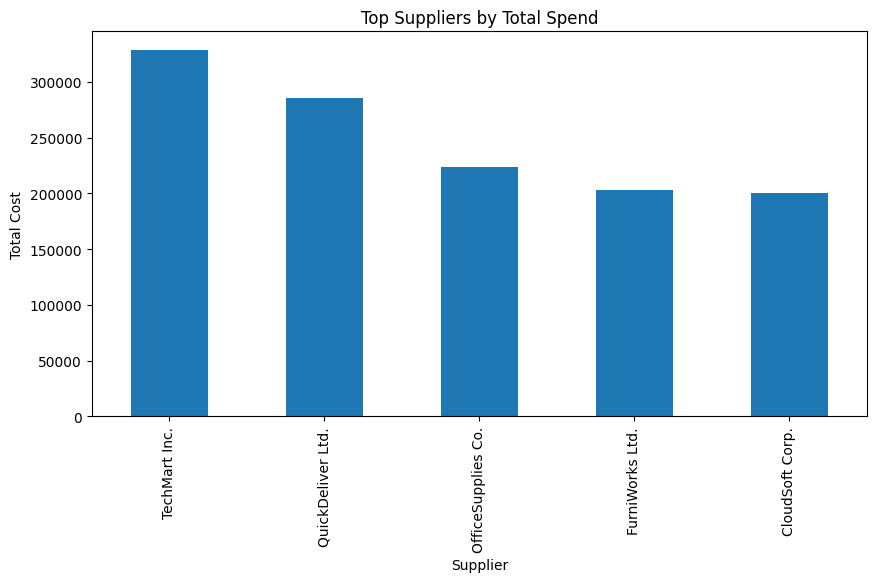

In [20]:
top_suppliers.plot(kind="bar", figsize=(10,5))

plt.title("Top Suppliers by Total Spend")

plt.xlabel("Supplier")

plt.ylabel("Total Cost")

plt.show()

In [21]:
df["LeakageScore"] = 0

In [22]:
duplicate_mask = df.duplicated(
    subset=["ItemName", "Supplier", "TotalCost"],
    keep=False
)

df.loc[duplicate_mask, "LeakageScore"] += 40

In [23]:
mean_cost = df["TotalCost"].mean()

std_cost = df["TotalCost"].std()

threshold = mean_cost + (2 * std_cost)

high_cost_mask = df["TotalCost"] > threshold

df.loc[high_cost_mask, "LeakageScore"] += 30

In [24]:
item_frequency = df["ItemName"].value_counts()

frequent_items = item_frequency[item_frequency > 5].index

In [25]:
df.loc[df["ItemName"].isin(frequent_items), "LeakageScore"] += 20

In [26]:
def risk_level(score):
    if score >= 60:
        return "High"
    elif score >= 30:
        return "Medium"
    else:
        return "Low"

df["RiskLevel"] = df["LeakageScore"].apply(risk_level)

In [27]:
df[[
    "TransactionID",
    "ItemName",
    "Supplier",
    "TotalCost",
    "LeakageScore",
    "RiskLevel"
]].head(20)

,TransactionID,ItemName,Supplier,TotalCost,LeakageScore,RiskLevel
0,TXN001,Desk Chair,TechMart Inc.,1131.50,20,Low
1,TXN002,Stapler,CloudSoft Corp.,201.92,20,Low
2,TXN003,Annual Software License,TechMart Inc.,5649.34,20,Low
3,TXN004,Notepad,FurniWorks Ltd.,37.96,20,Low
4,TXN005,Notepad,TechMart Inc.,26.41,20,Low
5,TXN006,Printer,FurniWorks Ltd.,2867.86,20,Low
6,TXN007,Notepad,OfficeSupplies Co.,21.84,20,Low
7,TXN008,Notepad,FurniWorks Ltd.,9.68,20,Low
8,TXN009,Printer Ink,FurniWorks Ltd.,154.57,20,Low
9,TXN010,Whiteboard,FurniWorks Ltd.,1915.58,20,Low


In [28]:
df["RiskLevel"].value_counts()

RiskLevel
Low       470
Medium     30
Name: count, dtype: int64

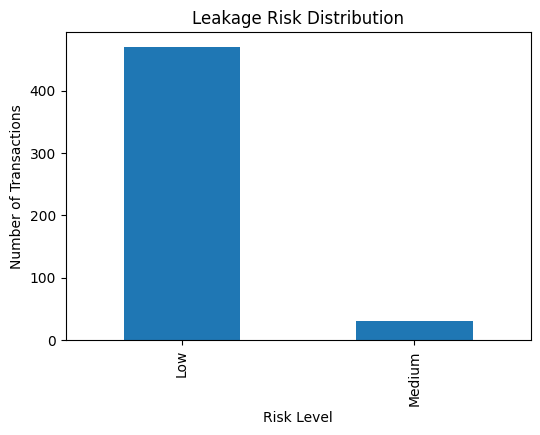

In [29]:
risk_counts = df["RiskLevel"].value_counts()

risk_counts.plot(kind="bar", figsize=(6,4))

plt.title("Leakage Risk Distribution")

plt.xlabel("Risk Level")

plt.ylabel("Number of Transactions")

plt.show()

In [30]:
df.to_csv("../outputs/leakage_analysis.csv", index=False)

In [31]:
df.to_csv("../outputs/leakage_analysis.csv", index=False)